In [20]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_fscore_support, hamming_loss,
)

import keras
from keras import layers

from transformers import pipeline as hf_pipeline

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

# ── Config ──────────────────────────────────────────────────────────────────────────────
N_SAMPLE     = 500                      # rows to embed  (CPU-only → keep small)
MAX_EMB_LEN  = 128                      # BERT token truncation
RANDOM_STATE = 42
CATS         = list('ABCDEFGHIJLMNZ')  # 14 MeSH root letter columns (no K)
TAU          = 1 / 14                  # uniform-prior threshold for multi-label eval

# § 2 — Load data

In [21]:
PATH = (r'C:\Users\Graham West\Python Notebooks\Meharry Teaching'
        r'\Datasets\PubMed Multiclass'
        r'\PubMed Multi Label Text Classification Dataset Processed.csv')

df = pd.read_csv(PATH)
print(f'{len(df):,} rows × {df.shape[1]} columns')
df.head(3)

50,000 rows × 20 columns


,Title,abstractText,meshMajor,pmid,meshid,meshroot,A,B,C,D,E,F,G,H,I,J,L,M,N,Z
0,Expression of p53 and coexistence of HPV in pr...,Fifty-four paraffin embedded tissue sections f...,"['DNA Probes, HPV', 'DNA, Viral', 'Female', 'H...",8549602,"[['D13.444.600.223.555', 'D27.505.259.750.600....","['Chemicals and Drugs [D]', 'Organisms [B]', '...",0,1,1,1,1,0,0,1,0,0,0,0,0,0
1,Vitamin D status in pregnant Indian women acro...,The present cross-sectional study was conducte...,"['Adult', 'Alkaline Phosphatase', 'Breast Feed...",21736816,"[['M01.060.116'], ['D08.811.277.352.650.035'],...","['Named Groups [M]', 'Chemicals and Drugs [D]'...",0,1,1,1,1,1,1,0,1,1,0,1,1,1
2,[Identification of a functionally important di...,The occurrence of individual amino acids and d...,"['Amino Acid Sequence', 'Analgesics, Opioid', ...",19060934,"[['G02.111.570.060', 'L01.453.245.667.060'], [...","['Phenomena and Processes [G]', 'Information S...",1,1,0,1,1,0,1,0,0,0,1,0,0,0


# § 3 — Label keys → topic names

The 14 single-letter columns (`A`–`Z`, skipping `K`) are already one-hot encoded in the CSV.  
Each letter maps to a **MeSH root category** (e.g. `D` = *Chemicals and Drugs*).  
We recover the human-readable name by parsing the `meshroot` column, which contains entries like `'Chemicals and Drugs [D]'`.

In [22]:
# ── Parse letter → topic name from the meshroot column ────────────────────────────
# meshroot values look like: "['Chemicals and Drugs [D]', 'Organisms [B]', ...]"
# Split on single-quote to extract each item, then rfind('[') to parse letter.

pairs = {}
for row in df['meshroot']:
    for item in str(row).split("'"):
        item = item.strip(', \n')
        if not item or '[' not in item or ']' not in item:
            continue
        idx    = item.rfind('[')
        letter = item[idx + 1 : idx + 2]
        topic  = item[:idx].strip()
        if letter in CATS and letter not in pairs:
            pairs[letter] = topic

KEY2TOPIC = dict(sorted(pairs.items()))
print(f'Found {len(KEY2TOPIC)} / {len(CATS)} letters\n')

pd.DataFrame({'Letter': list(KEY2TOPIC.keys()),
              'MeSH Root Topic': list(KEY2TOPIC.values())})

Found 14 / 14 letters



,Letter,MeSH Root Topic
0,A,Anatomy
1,B,Organisms
2,C,Diseases
3,D,Chemicals and Drugs
4,E,"Analytical, Diagnostic and Therapeutic Techniq..."
5,F,Psychiatry and Psychology
6,G,Phenomena and Processes
7,H,Disciplines and Occupations
8,I,"Anthropology, Education, Sociology, and Social..."
9,J,"Technology, Industry, and Agriculture"


# § 4 — EDA

Explore label prevalence, co-occurrence structure, and text length before subsampling.

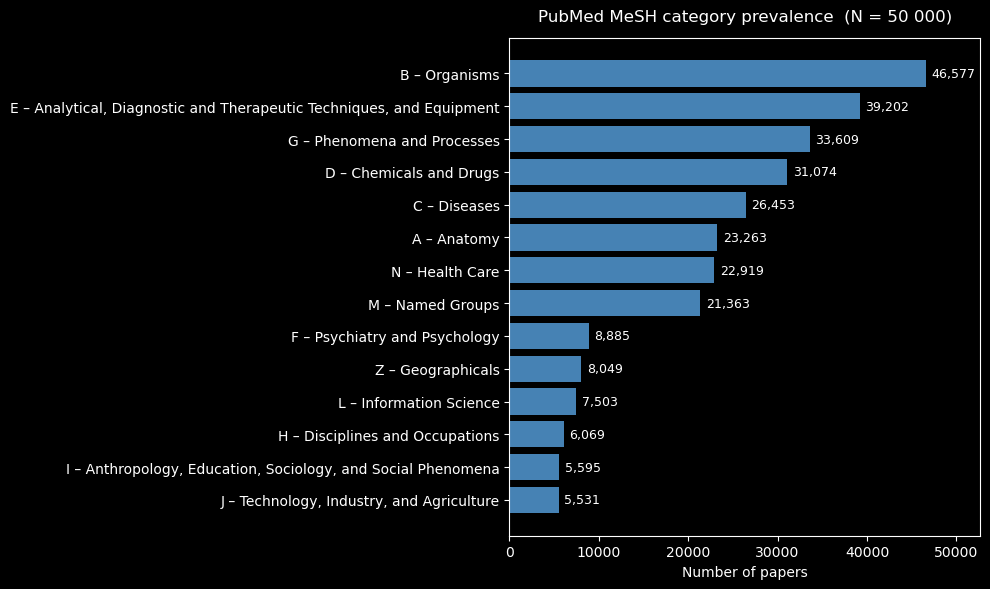

In [23]:
# ── Prevalence per category ─────────────────────────────────────────────────────────────────
counts = df[CATS].sum().rename(
    lambda c: f"{c} – {KEY2TOPIC.get(c, c)}"
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(counts.index, counts.values, color='steelblue', edgecolor='none')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Number of papers')
ax.set_title('PubMed MeSH category prevalence  (N = 50 000)', pad=12)
ax.set_xlim(0, counts.max() * 1.13)
plt.tight_layout()
plt.show()

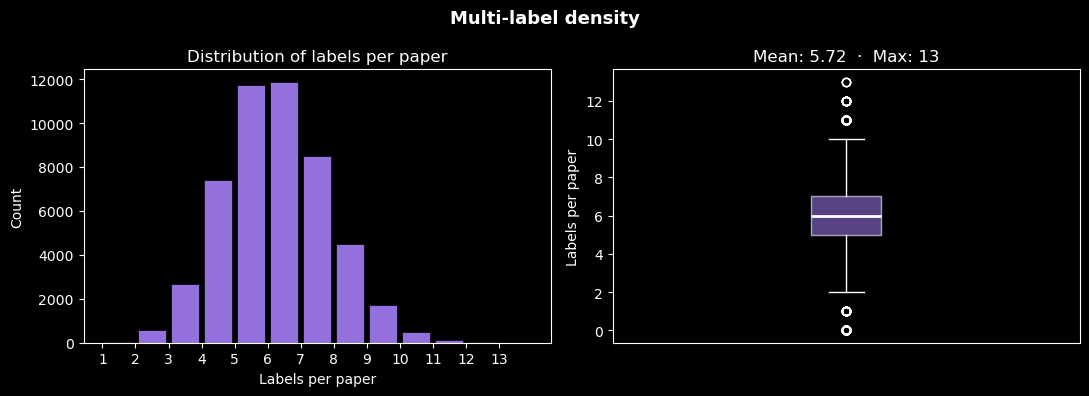

In [24]:
# ── Labels per row ────────────────────────────────────────────────────────────────────────
lab_counts = df[CATS].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(lab_counts, bins=range(1, int(lab_counts.max()) + 2),
             color='mediumpurple', edgecolor='black', linewidth=0.5, rwidth=0.85)
axes[0].set_xlabel('Labels per paper')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of labels per paper')
axes[0].set_xticks(range(1, int(lab_counts.max()) + 1))

axes[1].boxplot(lab_counts, vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumpurple', alpha=0.6),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_ylabel('Labels per paper')
axes[1].set_title(f'Mean: {lab_counts.mean():.2f}  ·  Max: {int(lab_counts.max())}')
axes[1].set_xticks([])

plt.suptitle('Multi-label density', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

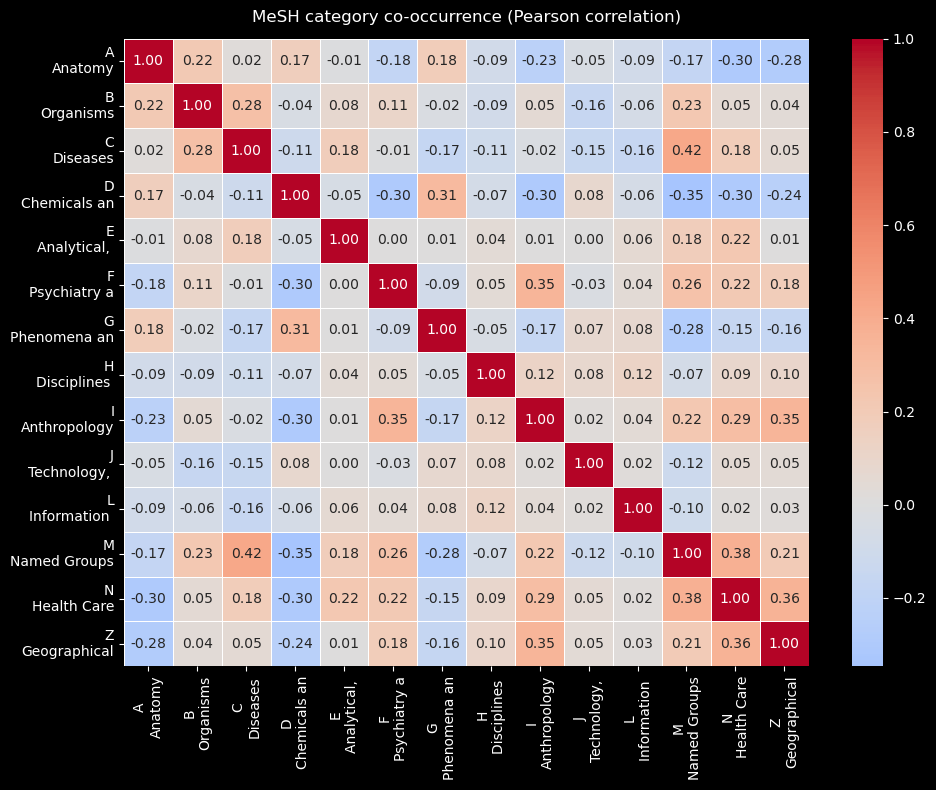

In [25]:
# ── Category co-occurrence heatmap ──────────────────────────────────────────────────────────
short_labels = [f"{c}\n{KEY2TOPIC.get(c, '')[:12]}" for c in CATS]
corr = df[CATS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.4, ax=ax)
ax.set_title('MeSH category co-occurrence (Pearson correlation)', pad=12)
plt.tight_layout()
plt.show()

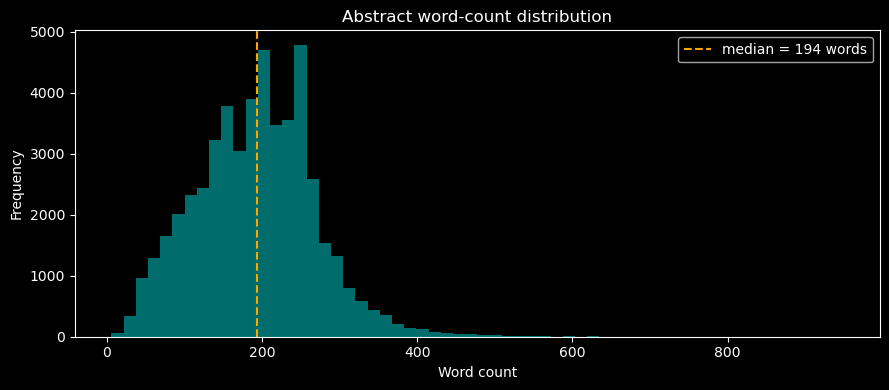


── Example papers ──────────────────────────────────────────────────────────────

Title : Vertical trauma: injuries to patients who fall and land on their feet.
Labels: B=Organisms, C=Diseases, F=Psychiatry and Psychology, I=Anthropology, Education, Sociology, and Social Phenomena, M=Named Groups, N=Health Care
Text  : We reviewed the patterns of injuries sustained by 12 consecutive fallers and jumpers in whom primary impact was onto the feet. The fall heights ranged from 20 to 100 ft. The 12 patients sustained 49 significant injuries.…

Title : The influence of bilateral sagittal split ramus osteotomy on submental-cervical aesthetics.
Labels: A=Anatomy, B=Organisms, E=Analytical, Diagnostic and Therapeutic Techniques, and Equipment, M=Named Groups, N=Health Care
Text  : The effect of orthodontic-surgical treatment on submental-cervical region was evaluated in a very limited number of studies. The aim of this study was to evaluate submental-cervical soft tissue contour changes followi

In [26]:
# ── Abstract word-count histogram ─────────────────────────────────────────────────────────
wc = df['abstractText'].fillna('').str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(wc, bins=60, color='teal', edgecolor='none', alpha=0.85)
ax.axvline(wc.median(), color='orange', linestyle='--',
           label=f'median = {wc.median():.0f} words')
ax.set_xlabel('Word count')
ax.set_ylabel('Frequency')
ax.set_title('Abstract word-count distribution')
ax.legend()
plt.tight_layout()
plt.show()

# ── A few example rows ──────────────────────────────────────────────────────────────────────
print('\n── Example papers ──────────────────────────────────────────────────────────────')
for _, row in df.sample(3, random_state=RANDOM_STATE).iterrows():
    cats_present = [f"{c}={KEY2TOPIC.get(c, c)}" for c in CATS if row[c] == 1]
    print(f"\nTitle : {row['Title']}")
    print(f"Labels: {', '.join(cats_present)}")
    print(f"Text  : {str(row['abstractText'])[:220]}…")

# § 5 — Subsample & build targets

We draw **~500 rows** using **balanced per-category sampling** — up to N_SAMPLE ÷ 14 rows per dominant MeSH category — so all categories are represented rather than dominated by the most prevalent ones.

The 14 binary label columns are **row-normalized** to a valid probability distribution (the KL-divergence training target). We also keep the raw multi-hot matrix (`Y_raw`) for multi-label evaluation and the dominant-category index (`y_dom`) for argmax evaluation.

In [27]:
# ── Balanced per-category sampling ───────────────────────────────────────────────────────────
clean = (
    df
    .dropna(subset=['Title', 'abstractText'])
    .loc[df[CATS].sum(axis=1) > 0]
    .copy()
)
clean['_dom'] = clean[CATS].values.argmax(axis=1)

n_cats    = clean['_dom'].nunique()
n_per_cat = N_SAMPLE // n_cats          # target rows per dominant category

sub = (
    clean
    .groupby('_dom', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), n_per_cat), random_state=RANDOM_STATE))
    .drop(columns='_dom')
    .reset_index(drop=True)
)
print(f'Subsample: {len(sub)} rows  ({n_per_cat} per category across {n_cats} dominant categories)')

# ── Show balance ─────────────────────────────────────────────────────────────────────────────
dom_sub = sub[CATS].values.argmax(axis=1)
balance = (pd.Series(dom_sub)
             .value_counts()
             .sort_index()
             .rename(index=lambda i: f'{CATS[i]} – {KEY2TOPIC.get(CATS[i], "")}'))
print('\nDominant-category counts in subsample:')
print(balance.to_string())

# ── Texts ────────────────────────────────────────────────────────────────────────────────────
texts = (sub['Title'].str.strip() + '. ' + sub['abstractText'].str.strip()).tolist()

# ── Label matrices ───────────────────────────────────────────────────────────────────────────
Y_raw  = sub[CATS].values.astype(float)
Y_dist = Y_raw / Y_raw.sum(axis=1, keepdims=True)  # row-normalize → prob dist (KL target)
y_dom  = Y_raw.argmax(axis=1)

print(f'\nY_dist row-sum check (first 5): {Y_dist.sum(axis=1)[:5].round(3)}')

# ── Train / test split (shared across all embeddings) ────────────────────────────────────────
idx = np.arange(len(sub))
try:
    idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE,
                                      stratify=y_dom)
    print('Stratified split OK')
except ValueError:
    idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE)
    print('Note: stratification skipped (too few samples in some classes)')

print(f'Train: {len(idx_tr)}  ·  Test: {len(idx_te)}')

Subsample: 366 rows  (38 per category across 13 dominant categories)

Dominant-category counts in subsample:
A – Anatomy                                                             38
B – Organisms                                                           38
C – Diseases                                                            32
D – Chemicals and Drugs                                                 38
E – Analytical, Diagnostic and Therapeutic Techniques, and Equipment    38
F – Psychiatry and Psychology                                           30
G – Phenomena and Processes                                             38
H – Disciplines and Occupations                                         38
I – Anthropology, Education, Sociology, and Social Phenomena            38
J – Technology, Industry, and Agriculture                               10
L – Information Science                                                 14
M – Named Groups                                                  

# § 6 — Generate embeddings

We embed every text with **six biomedical BERT models** using mean-pooling of the last hidden state — the same pattern as `U2-1_NLP_08_PubMed.ipynb`.

> This is the slow cell — expect ~10–20 min on CPU for 500 texts × 6 models.

In [28]:
# ── Six BERT models to compare ────────────────────────────────────────────────────────────────
BERT_MODELS = {
    'BERT-base':        'bert-base-uncased',
    'ClinicalBERT':     'medicalai/ClinicalBERT',
    'Bio_ClinicalBERT': 'emilyalsentzer/Bio_ClinicalBERT',
    'PubMedBERT':       'microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract',
    'SciBERT':          'allenai/scibert_scivocab_uncased',
}

# ── Mean-pool embedding helper ───────────────────────────────────────────────────────────
def embed_texts_hf(model_name, texts, max_len=MAX_EMB_LEN, log_every=25):
    """
    HuggingFace feature-extraction pipeline → mean-pool → (N, hidden_dim) array.
    Same pattern as U2-1_NLP_08_PubMed.ipynb §5.
    """
    pipe = hf_pipeline('feature-extraction', model=model_name)
    vecs = []
    for i, t in enumerate(texts):
        out = np.array(
            pipe(t, tokenize_kwargs={'truncation': True, 'max_length': max_len})
        )[0]                          # drop batch dim → (num_tokens, hidden_dim)
        vecs.append(out.mean(axis=0)) # mean-pool over tokens → (hidden_dim,)
        if (i + 1) % log_every == 0:
            print(f'    [{i+1}/{len(texts)}]')
    return np.vstack(vecs)

In [29]:
embeddings = {}

for short_name, model_id in BERT_MODELS.items():
    print(f'\n── {short_name}  ({model_id}) ──')
    E = embed_texts_hf(model_id, texts)
    embeddings[short_name] = E
    print(f'   Shape: {E.shape}')

print('\nDone.')
for k, v in embeddings.items():
    print(f'  {k:20s}  {v.shape}')


── BERT-base  (bert-base-uncased) ──


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [25/366]
    [50/366]
    [75/366]
    [100/366]
    [125/366]
    [150/366]
    [175/366]
    [200/366]
    [225/366]
    [250/366]
    [275/366]
    [300/366]
    [325/366]
    [350/366]
   Shape: (366, 768)

── ClinicalBERT  (medicalai/ClinicalBERT) ──


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [25/366]
    [50/366]
    [75/366]
    [100/366]
    [125/366]
    [150/366]
    [175/366]
    [200/366]
    [225/366]
    [250/366]
    [275/366]
    [300/366]
    [325/366]
    [350/366]
   Shape: (366, 768)

── SciBERT  (allenai/scibert_scivocab_uncased) ──


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [25/366]
    [50/366]
    [75/366]
    [100/366]
    [125/366]
    [150/366]
    [175/366]
    [200/366]
    [225/366]
    [250/366]
    [275/366]
    [300/366]
    [325/366]
    [350/366]
   Shape: (366, 768)

Done.
  BERT-base             (366, 768)
  ClinicalBERT          (366, 768)
  Bio_ClinicalBERT      (366, 768)
  PubMedBERT            (366, 768)
  SciBERT               (366, 768)


# § 7 — Embedding visualization

We project each embedding set to 2D with **PCA** and **t-SNE** and color points by the **dominant MeSH category** (argmax of the multi-hot labels).

> Since papers often carry multiple labels, coloring by dominant category is a simplification — nearby points may share several categories beyond the one displayed.

In [30]:
# ── Color palette for 14 categories ───────────────────────────────────────────────────────────
cmap   = plt.cm.get_cmap('tab20', len(CATS))
colors = [cmap(i) for i in range(len(CATS))]

legend_patches = [
    mpatches.Patch(color=colors[i],
                   label=f"{CATS[i]}  {KEY2TOPIC.get(CATS[i], '')[:22]}")
    for i in range(len(CATS))
]
model_names = list(embeddings.keys())

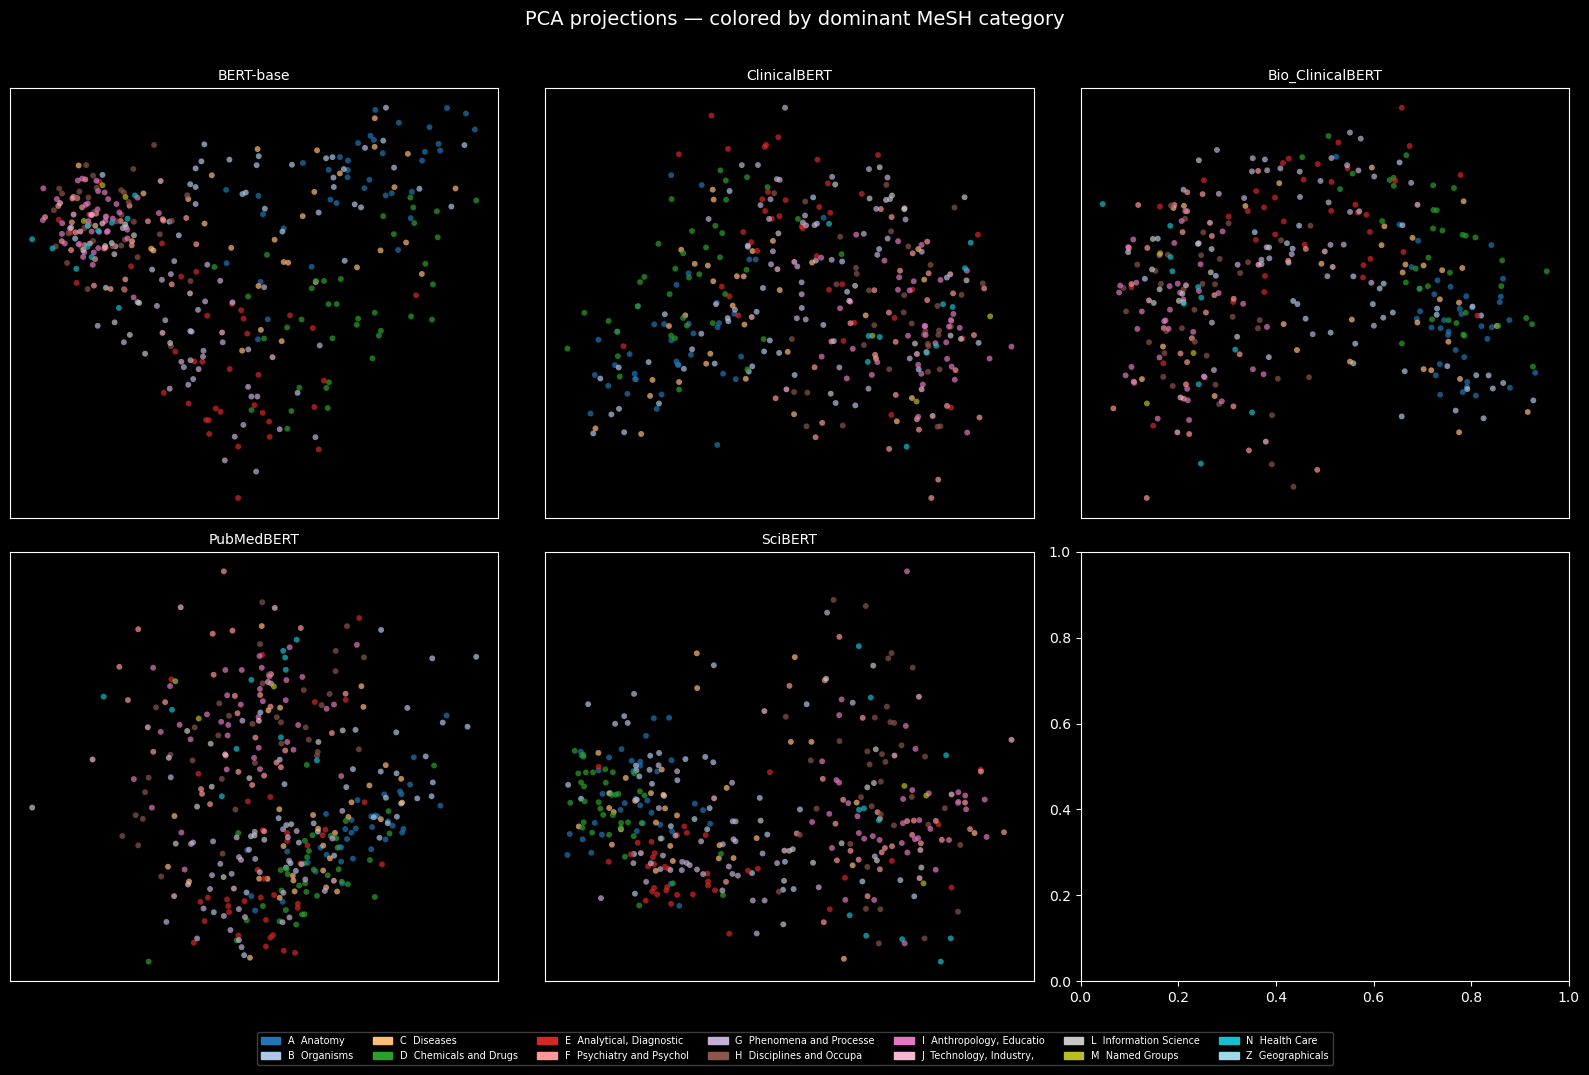

In [31]:
# ── PCA 2×3 grid ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PCA projections — colored by dominant MeSH category',
             fontsize=14, y=1.01)

for ax, name in zip(axes.flat, model_names):
    E    = embeddings[name]
    proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(E)
    c_vals = [colors[y_dom[i]] for i in range(len(y_dom))]
    ax.scatter(proj[:, 0], proj[:, 1], c=c_vals, s=18, alpha=0.7, linewidths=0)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.legend(handles=legend_patches, loc='lower center', ncol=7,
           fontsize=7, framealpha=0.3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

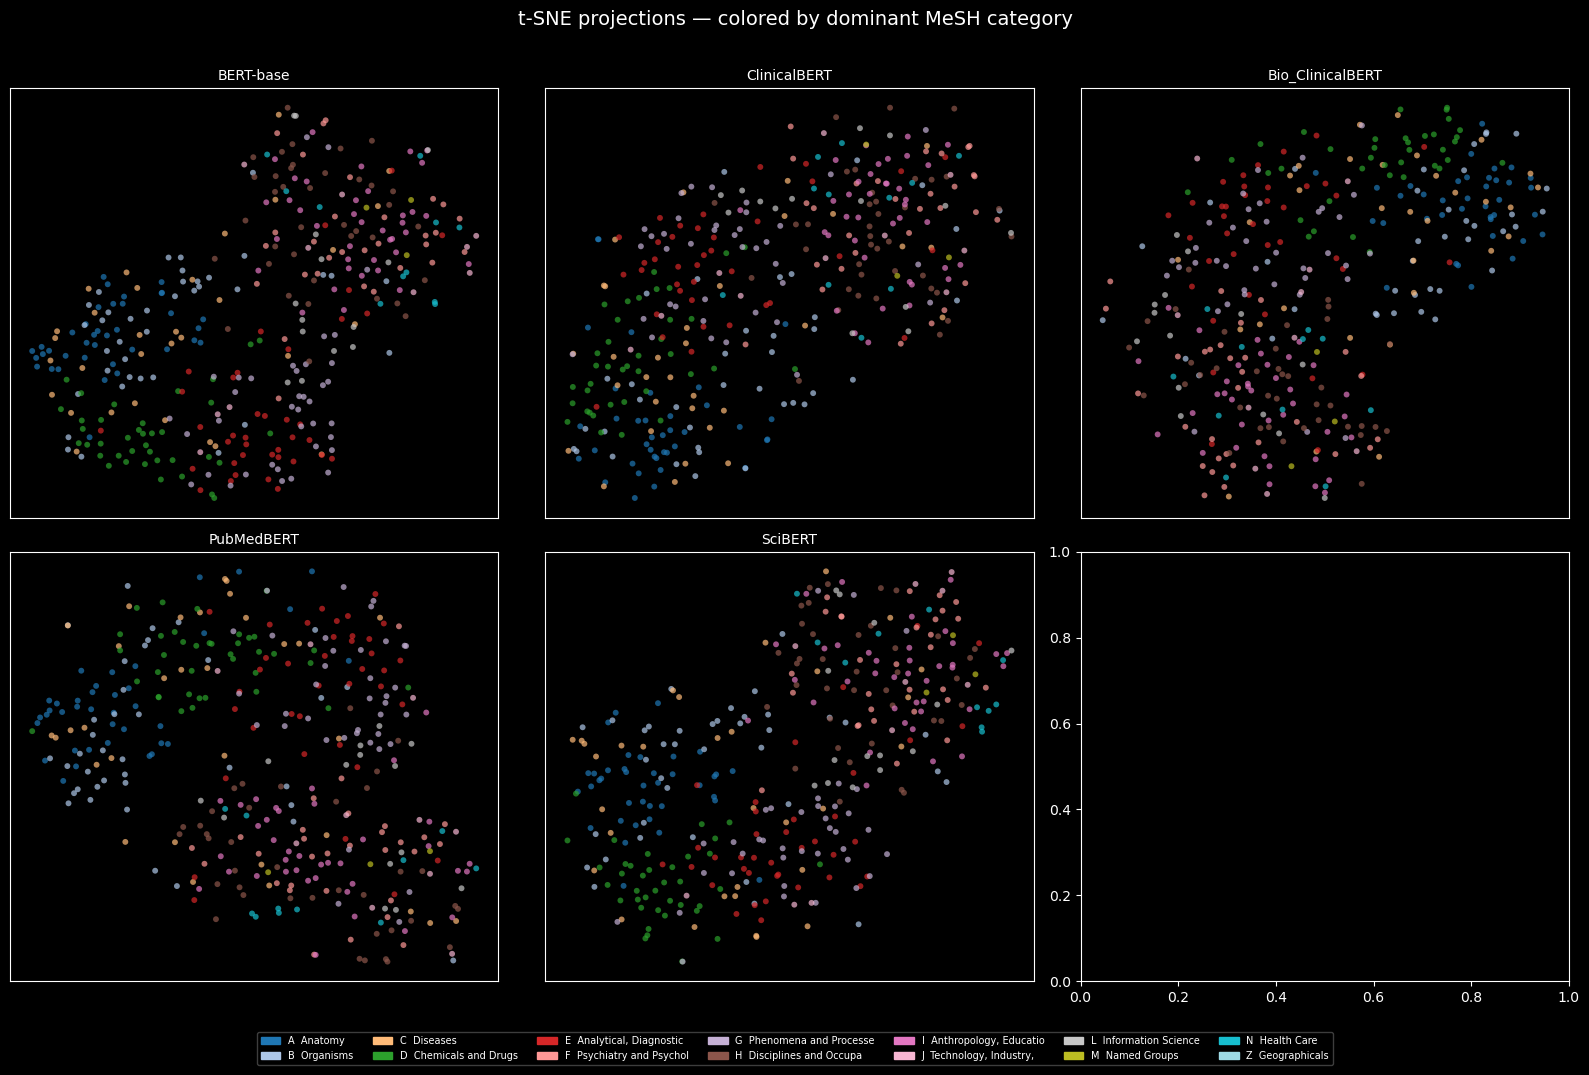

In [32]:
# ── t-SNE 2×3 grid ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('t-SNE projections — colored by dominant MeSH category',
             fontsize=14, y=1.01)

for ax, name in zip(axes.flat, model_names):
    E    = embeddings[name]
    proj = TSNE(n_components=2, perplexity=30, init='pca',
                random_state=RANDOM_STATE).fit_transform(E)
    c_vals = [colors[y_dom[i]] for i in range(len(y_dom))]
    ax.scatter(proj[:, 0], proj[:, 1], c=c_vals, s=18, alpha=0.7, linewidths=0)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.legend(handles=legend_patches, loc='lower center', ncol=7,
           fontsize=7, framealpha=0.3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# § 8 — Keras dense network with KL-divergence loss

We treat the row-normalized label vector as a **target probability distribution** and train with `KLDivergence` — a natural fit for soft multi-label targets.

**Architecture:** `Dense(256, relu) → Dropout(0.3) → Dense(128, relu) → Dense(14, softmax)`  
One fresh model is trained per embedding set; all share the same architecture and hyperparameters.

In [33]:
def build_model(input_dim, n_classes=14):
    """Small dense classifier with KL-divergence loss."""
    inp = keras.Input(shape=(input_dim,))
    x   = layers.Dense(256, activation='relu')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer='adam',
        loss=keras.losses.KLDivergence(),
        metrics=['mae'],
    )
    return model

# ── Inverse-frequency sample weights (counteract dominant-category imbalance) ────────────────
sw_tr = compute_sample_weight('balanced', y_dom[idx_tr])

# ── Train one model per embedding ────────────────────────────────────────────────────────────
histories      = {}
trained_models = {}

for name, E in embeddings.items():
    print(f'\n── Training on {name} embeddings ──')
    X_tr, X_te = E[idx_tr], E[idx_te]
    Y_tr, Y_te = Y_dist[idx_tr], Y_dist[idx_te]

    model = build_model(E.shape[1])
    cb = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True
    )
    hist = model.fit(
        X_tr, Y_tr,
        sample_weight=sw_tr,
        validation_data=(X_te, Y_te),
        epochs=50,
        batch_size=32,
        callbacks=[cb],
        verbose=0,
    )
    histories[name]      = hist
    trained_models[name] = model
    best_val = min(hist.history['val_loss'])
    print(f'   Best val_loss = {best_val:.4f}  '
          f'(stopped at epoch {len(hist.history["val_loss"])})')


── Training on BERT-base embeddings ──
   Best val_loss = 0.6435  (stopped at epoch 46)

── Training on ClinicalBERT embeddings ──
   Best val_loss = 0.7565  (stopped at epoch 27)

── Training on Bio_ClinicalBERT embeddings ──
   Best val_loss = 0.7135  (stopped at epoch 34)

── Training on PubMedBERT embeddings ──
   Best val_loss = 0.6623  (stopped at epoch 28)

── Training on SciBERT embeddings ──
   Best val_loss = 0.6627  (stopped at epoch 17)


# § 9 — Validation-loss comparison

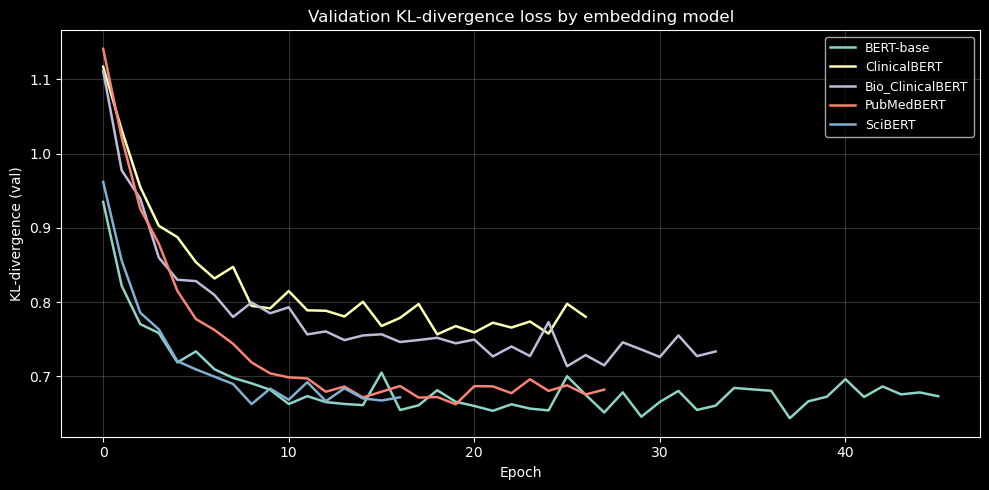

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, hist in histories.items():
    ax.plot(hist.history['val_loss'], label=name, linewidth=1.8)

ax.set_xlabel('Epoch')
ax.set_ylabel('KL-divergence (val)')
ax.set_title('Validation KL-divergence loss by embedding model')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# § 10 — Metrics comparison

We evaluate each model under **two framings**:

1. **Argmax / multiclass** — reduce predictions and true labels to their dominant-category index; report accuracy and macro-F1.
2. **Multi-label / thresholded** — threshold the softmax output at τ = 1/14 (the uniform prior) to recover a binary prediction per label; report subset accuracy, macro-F1, micro-F1, and Hamming loss.

Softmax+KL training spreads probability mass across all 14 labels, so a threshold near the uniform prior (≈ 0.071) is a natural starting point.

In [35]:
# ── Generate test-set predictions for every model ─────────────────────────────────────────
preds_prob = {}
for name, model in trained_models.items():
    preds_prob[name] = model.predict(embeddings[name][idx_te], verbose=0)

# Ground-truth for the test set
Y_te_raw    = Y_raw[idx_te]    # (N_te, 14) multi-hot
y_dom_te    = y_dom[idx_te]    # (N_te,)    dominant-category index
topic_labels = [KEY2TOPIC.get(c, c) for c in CATS]

Argmax (dominant-category) metrics


,Accuracy,Macro-F1
Model,,
BERT-base,0.216,0.211
PubMedBERT,0.216,0.207
ClinicalBERT,0.135,0.125
SciBERT,0.176,0.118
Bio_ClinicalBERT,0.149,0.112



── Classification report: BERT-base (argmax) ──
                                                                  precision    recall  f1-score   support

                                                         Anatomy       1.00      0.14      0.25         7
                                                       Organisms       0.00      0.00      0.00         8
                                                        Diseases       0.33      0.17      0.22         6
                                             Chemicals and Drugs       0.33      0.38      0.35         8
Analytical, Diagnostic and Therapeutic Techniques, and Equipment       0.00      0.00      0.00         8
                                       Psychiatry and Psychology       0.00      0.00      0.00         6
                                         Phenomena and Processes       0.31      0.50      0.38         8
                                     Disciplines and Occupations       0.33      0.12      0.18       

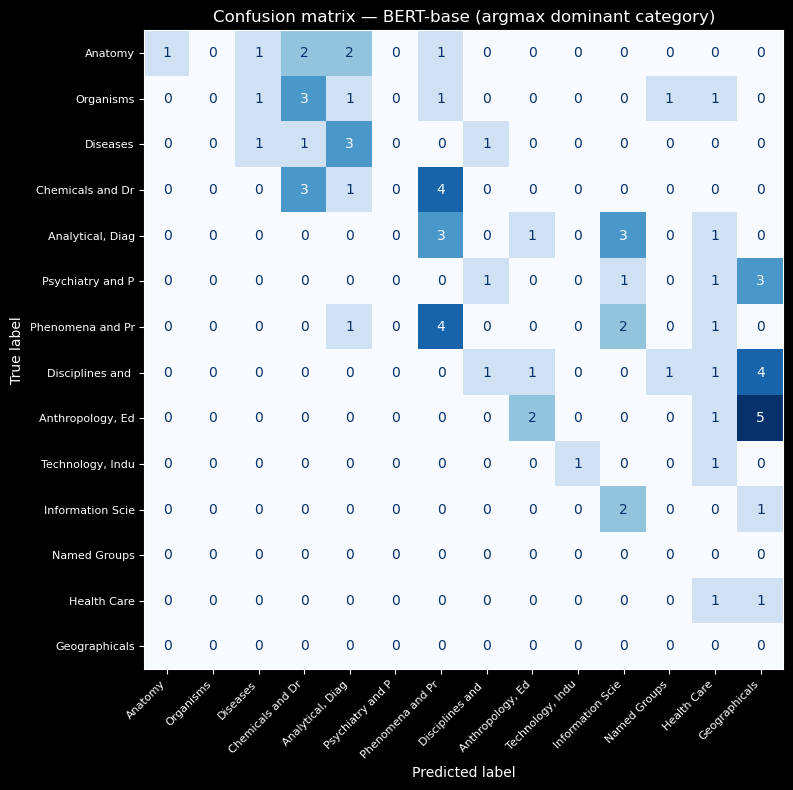

In [36]:
# ── A. Argmax / multiclass metrics ──────────────────────────────────────────────────────────────
records_argmax = []
for name, P in preds_prob.items():
    y_pred_dom = P.argmax(axis=1)
    acc = accuracy_score(y_dom_te, y_pred_dom)
    f1  = f1_score(y_dom_te, y_pred_dom, average='macro', zero_division=0)
    records_argmax.append({'Model': name, 'Accuracy': acc, 'Macro-F1': f1})

df_argmax = (pd.DataFrame(records_argmax)
               .set_index('Model')
               .sort_values('Macro-F1', ascending=False))
print('Argmax (dominant-category) metrics')
display(df_argmax.style.format('{:.3f}').background_gradient(cmap='Blues', axis=0))

# ── Confusion matrix + report for the best argmax model ───────────────────────────────
best_name = df_argmax['Macro-F1'].idxmax()
best_pred = preds_prob[best_name].argmax(axis=1)

print(f'\n── Classification report: {best_name} (argmax) ──')
print(classification_report(y_dom_te, best_pred,
                             labels=list(range(len(CATS))),
                             target_names=topic_labels,
                             zero_division=0))

fig, ax = plt.subplots(figsize=(11, 8))
ConfusionMatrixDisplay.from_predictions(
    y_dom_te, best_pred,
    labels=list(range(len(CATS))),
    display_labels=[t[:16] for t in topic_labels],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion matrix — {best_name} (argmax dominant category)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [37]:
# ── B. Multi-label / thresholded metrics ────────────────────────────────────────────────────
print(f'Threshold τ = {TAU:.4f}  (= 1 / {len(CATS)} uniform prior)')

records_ml = []
for name, P in preds_prob.items():
    Y_pred_bin = (P >= TAU).astype(int)
    # Guarantee at least 1 positive prediction per row
    no_pos = Y_pred_bin.sum(axis=1) == 0
    Y_pred_bin[no_pos, P[no_pos].argmax(axis=1)] = 1

    macro_f1 = f1_score(Y_te_raw, Y_pred_bin, average='macro',  zero_division=0)
    micro_f1 = f1_score(Y_te_raw, Y_pred_bin, average='micro',  zero_division=0)
    sub_acc  = accuracy_score(Y_te_raw, Y_pred_bin)  # subset accuracy
    h_loss   = hamming_loss(Y_te_raw, Y_pred_bin)
    records_ml.append({
        'Model':        name,
        'Subset Acc':   sub_acc,
        'Macro-F1':     macro_f1,
        'Micro-F1':     micro_f1,
        'Hamming Loss': h_loss,
    })

df_ml = (pd.DataFrame(records_ml)
           .set_index('Model')
           .sort_values('Micro-F1', ascending=False))
print('\nMulti-label (thresholded) metrics')
display(
    df_ml.style
         .format('{:.3f}')
         .background_gradient(cmap='Greens', subset=['Macro-F1', 'Micro-F1'])
         .background_gradient(cmap='Reds_r', subset=['Hamming Loss'])
)

Threshold τ = 0.0714  (= 1 / 14 uniform prior)

Multi-label (thresholded) metrics


,Subset Acc,Macro-F1,Micro-F1,Hamming Loss
Model,,,,
BERT-base,0.095,0.684,0.752,0.153
PubMedBERT,0.108,0.669,0.725,0.173
SciBERT,0.041,0.652,0.725,0.171
Bio_ClinicalBERT,0.081,0.598,0.699,0.187
ClinicalBERT,0.095,0.587,0.694,0.189


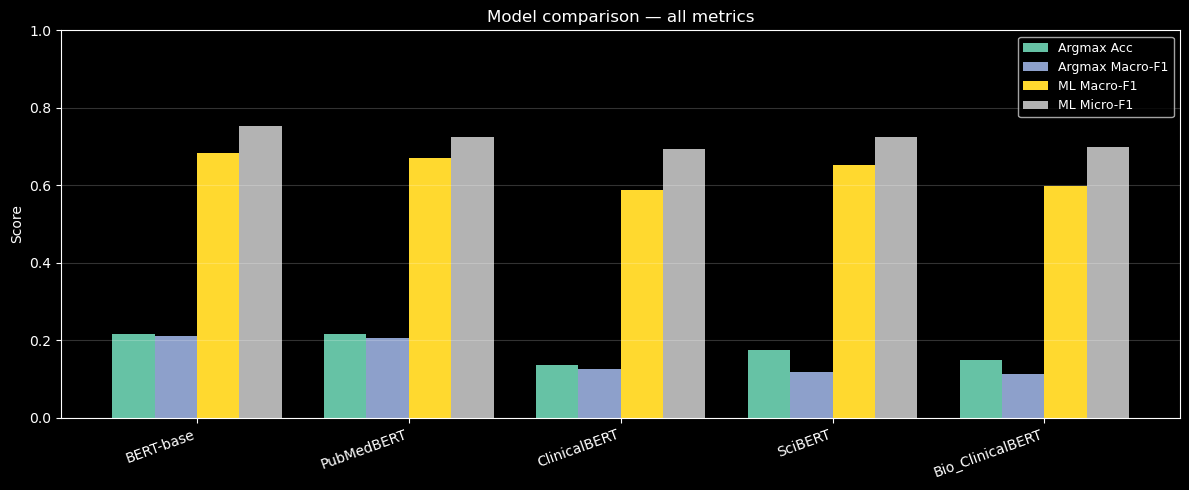


── Final leaderboard ──


,Argmax Acc,Argmax Macro-F1,ML Macro-F1,ML Micro-F1,Hamming Loss
Model,,,,,
BERT-base,0.216,0.211,0.684,0.752,0.153
PubMedBERT,0.216,0.207,0.669,0.725,0.173
ClinicalBERT,0.135,0.125,0.587,0.694,0.189
SciBERT,0.176,0.118,0.652,0.725,0.171
Bio_ClinicalBERT,0.149,0.112,0.598,0.699,0.187


In [38]:
# ── C. Leaderboard bar chart ───────────────────────────────────────────────────────────────────
leaderboard = (
    df_argmax
    .rename(columns={'Accuracy': 'Argmax Acc', 'Macro-F1': 'Argmax Macro-F1'})
    .join(df_ml[['Macro-F1', 'Micro-F1', 'Hamming Loss']]
            .rename(columns={'Macro-F1': 'ML Macro-F1', 'Micro-F1': 'ML Micro-F1'}))
)

plot_cols = ['Argmax Acc', 'Argmax Macro-F1', 'ML Macro-F1', 'ML Micro-F1']
x    = np.arange(len(leaderboard))
w    = 0.2
bar_cmap = plt.cm.get_cmap('Set2', len(plot_cols))

fig, ax = plt.subplots(figsize=(12, 5))
for j, col in enumerate(plot_cols):
    ax.bar(x + j * w, leaderboard[col], width=w, label=col,
           color=bar_cmap(j), edgecolor='none')

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(leaderboard.index, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model comparison — all metrics')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

print('\n── Final leaderboard ──')
display(leaderboard.style.format('{:.3f}'))

# § 11 — Summary

## What we did
We embedded 500 PubMed abstracts with six biomedical BERT models (mean-pooled, truncated at 128 tokens), then trained a small dense Keras network on each set of embeddings using **KL-divergence loss** with row-normalized multi-label targets.

## Why KL-divergence for multi-label?
Multi-label targets normalized to a probability distribution encode *relative label salience*, not just presence/absence.  
KL-divergence penalizes the network for confidently misallocating probability mass, encouraging the model to spread its softmax output proportionally to the label co-occurrence structure of each paper.

## Expected ranking
Models pre-trained on biomedical literature — **PubMedBERT**, **BioBERT**, and **SciBERT** — typically outperform the general-purpose `bert-base-uncased`.  
`ClinicalBERT` and `Bio_ClinicalBERT` are tuned on clinical notes, so they may lag slightly on basic-science abstracts.

## Two evaluation framings

| Framing | Method | Captures |
|---|---|---|
| Argmax / multiclass | argmax of prediction vs. argmax of truth | Dominant-category discrimination |
| Multi-label thresholded (τ = 1/14) | softmax ≥ τ → binary mask | Full multi-label structure |

## Extensions to try
- **CLS pooling** instead of mean pooling: change `out.mean(axis=0)` → `out[0]`  
- **Top-*k* thresholding** instead of τ: predict exactly *k* labels per paper  
- **Larger sample** — try 2 000–5 000 rows once embeddings are cached  
- **Class-weighted loss** — upweight rare categories (e.g. `Z` = Geographicals)  
- **Sentence-transformers baseline** — `all-MiniLM-L6-v2` embeds much faster on CPU